In [1]:
import torch.nn as nn
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import torch.nn.functional as F

device = torch.device("cpu")
transform = transforms.ToTensor()
test_ds = datasets.MNIST(root="", train=False, download=True, transform=transform)
test_loader = DataLoader(test_ds, batch_size=56, shuffle=False)

model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28*28, 256),
    nn.ReLU(),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
).to(device)

model.load_state_dict(torch.load("mlp_mnist_state_dict.pt", map_location=device))
model.eval()


def get_activations_for_all_digits(model):
    acts = {}
    digit_activations = {x: [] for x in range(10)}

    def save_activation(name):
        def hook(module, inp, out):
            acts[name] = out.detach()
        return hook

    h1 = model[2].register_forward_hook(save_activation("a1"))#create forward hook on this and call it a1
    h2 = model[4].register_forward_hook(save_activation("a2"))#create forward hook on this and call it a2
    h3 = model[5].register_forward_hook(save_activation("a3"))

    with torch.no_grad():
        for x, y in test_loader:
            x = x.to(device)
            y = y.to(device)

            _ = model(x)
            
            a1 = acts.pop("a1")#these are of length(batch) and contain activations for each value in y 
            a2 = acts.pop("a2")
            a3 = acts.pop("a3")

  
            for i in range(len(y)):#iterate through y
                digit = y[i].item()#cast tensor to python int
                digit_activations[digit].append([a1[i], a2[i], a3[i]])#take slices out of a1, a2, and a3

        h1.remove()#remove hooks when done
        h2.remove()
        h3.remove()

        return digit_activations

In [2]:
results = get_activations_for_all_digits(model)

In [3]:
avg_activations = {}#this is a dict
output = {}

for digit in range(10):#for every value
    #this is just nested iterators
    layer_2_avg = torch.stack([act[1] for act in results[digit]]).mean(dim=0)#
    #result is iterated
    avg_activations[digit] = layer_2_avg
    output[digit] = torch.stack([act[2] for act in results[digit]]).mean(dim=0)#finds mean activations 

#main idea here
#for each value 

In [4]:
print(output[1])

# Extract just layer 2 average activations for all digits
layer2_avgs = torch.stack([avg_activations[i] for i in range(10)])
# Shape: [10, 128] - 10 digits, 128 neurons each

# Calculate cosine similarity matrix
similarity_matrix = F.cosine_similarity(
    layer2_avgs.unsqueeze(1),  # [10, 1, 128]
    layer2_avgs.unsqueeze(0),  # [1, 10, 128]
    dim=2
)
# Shape: [10, 10]

#print(similarity_matrix)

tensor([-8.0221,  8.6920, -3.2869, -3.1846, -1.2420, -6.0383, -4.0992, -1.8172,
        -0.5209, -3.1125])


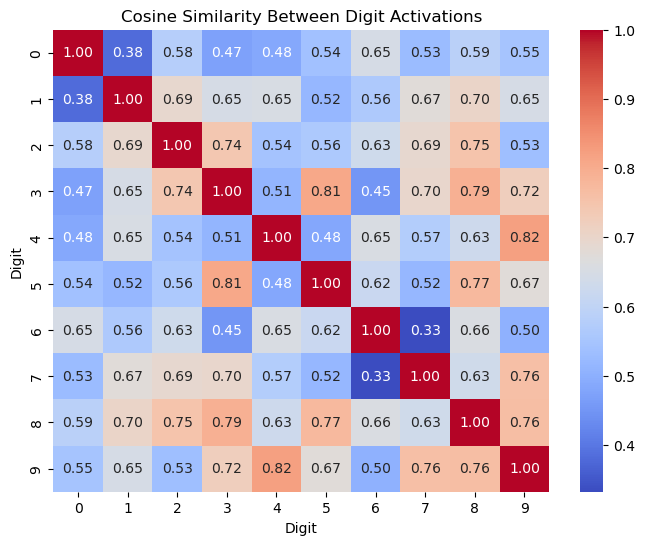

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(similarity_matrix.numpy(), annot=True, fmt='.2f', 
            xticklabels=range(10), yticklabels=range(10), cmap='coolwarm')
plt.title('Cosine Similarity Between Digit Activations')
plt.xlabel('Digit')
plt.ylabel('Digit')
plt.show()

In [6]:
horizontal_sums = similarity_matrix.sum(dim=1)
print(horizontal_sums)
print(horizontal_sums.argmax().item())
print(horizontal_sums.argmin().item())

tensor([5.7611, 6.4767, 6.7280, 6.8416, 6.3559, 6.4887, 6.0559, 6.4089, 7.2918,
        6.9749])
8
0


In [7]:
#8 is the most similar number as the sum of its similarities are highest
#2 of its highest similarities are with non loopy numbers 
#0 is least similar and its highest similarity is with 6
#conclusion - i cannot conclusively state that there is or isn't a loop feature

In [8]:
#plan 

In [47]:
end_neurons = model[5].weight.detach().cpu()
print(end_neurons.mean(dim=-2))

def find_common_hidden_units(digit_a, digit_b, k=20, min_weight=0.0):#if min_weight=0, all activiations will be examined. i will keep it as zero for identifying the loop feature and then crank it higher
    wa = end_neurons[digit_a]
    wb = end_neurons[digit_b]

    a_min_weight = wa[wa>0].quantile(0.75).item()

    #defining boolean masks
    shared_pos_mask = (wa > min_weight) & (wb > min_weight)
    shared_neg_mask = (wa < -min_weight) & (wb < -min_weight)
    opposite_mask = (wa * wb < 0)#cause negative numbers are less than 0. this will catch positive / negative pairs

    #score shared positives 
    shared_pos_score = torch.minimum(wa, wb).clone()
    shared_pos_score[~shared_pos_mask] = -float("inf")

    #scored shared negatives
    shared_neg_score = torch.minimum(-wa, -wb).clone()
    shared_neg_score[~shared_neg_mask] = -float("inf")

    #score differences
    opposites = (wa - wb).abs().clone()
    opposites[~opposite_mask] = -float("inf")

    top_pos_vals, top_pos_idx = torch.topk(shared_pos_score, k=min(k, shared_pos_mask.sum().item()))
    top_neg_vals, top_neg_idx = torch.topk(shared_neg_score, k=min(k, shared_neg_mask.sum().item()))
    top_con_vals, top_con_idx = torch.topk(opposites,   k=min(k, opposite_mask.sum().item()))

    return {
        "cosine_similarity": F.cosine_similarity(wa.unsqueeze(0), wb.unsqueeze(0)).item(),
        "shared_positive": list(top_pos_idx.tolist()),
        "shared_negative": list(top_neg_idx.tolist()),
        "opposites": list(top_con_idx.tolist()),
    }

tensor([-0.0192, -0.0212, -0.0255, -0.0207, -0.0234, -0.0163, -0.0149,  0.0153,
        -0.0312,  0.0216,  0.0174, -0.0709, -0.0309, -0.0094,  0.0030,  0.0036,
        -0.0217, -0.0046, -0.0357, -0.0363, -0.0118, -0.0169, -0.0488, -0.0357,
         0.0005, -0.0214,  0.0208, -0.0121,  0.0104,  0.0185, -0.0244, -0.0138,
        -0.0285, -0.0156,  0.0066,  0.0084, -0.0139, -0.0188, -0.0233, -0.0100,
        -0.0151, -0.0126, -0.0159, -0.0372, -0.0391, -0.0510, -0.0467,  0.0031,
        -0.0235, -0.0310, -0.0098,  0.0047, -0.0149, -0.0358, -0.0348,  0.0023,
        -0.0381, -0.0374, -0.0004,  0.0088, -0.0450, -0.0003, -0.0089,  0.0031,
        -0.0304, -0.0760,  0.0023, -0.0376, -0.0395,  0.0251, -0.0166, -0.0093,
         0.0182,  0.0252, -0.0028, -0.0044,  0.0015, -0.0311,  0.0402, -0.0157,
        -0.0205, -0.0280, -0.0302, -0.0361, -0.0285, -0.0250,  0.0013, -0.0093,
        -0.0323, -0.0157,  0.0126, -0.0028, -0.0337, -0.0112, -0.0002, -0.0180,
        -0.0069, -0.0308, -0.0208, -0.04

In [48]:
res = find_common_hidden_units(8, 9, k=128)
print("cosine:", res["cosine_similarity"])
print("shared positive:", res["shared_positive"])
print("shared negative:", res["shared_negative"])
print("contrastive:", res["opposites"])

cosine: -0.0035945437848567963
shared positive: [109, 29, 122, 40, 90, 0, 41, 66, 7, 55, 9, 12, 26, 74, 87, 76, 120, 106, 16, 35, 49, 105, 117, 91, 72, 83, 71]
shared negative: [33, 78, 121, 45, 46, 108, 97, 63, 61, 88, 3, 11, 2, 37, 13, 38, 6, 115, 32, 52, 79, 22, 75, 25, 113, 92, 5, 82, 59, 95, 27, 70, 64, 48, 96]
contrastive: [85, 57, 62, 47, 18, 84, 4, 65, 104, 23, 119, 50, 60, 124, 111, 44, 101, 81, 127, 10, 107, 86, 67, 69, 53, 17, 123, 31, 24, 102, 116, 20, 103, 77, 39, 36, 98, 8, 100, 19, 118, 126, 89, 80, 51, 34, 28, 58, 99, 1, 114, 68, 94, 93, 30, 73, 15, 42, 112, 125, 110, 43, 14, 56, 54, 21]


In [49]:
loopy_digits = [0, 6, 9, 8]
results = {}



for outer_digit in loopy_digits:
    temp_array = {}
    for inner_digit in loopy_digits:
        if outer_digit == inner_digit:
            continue
        temp = find_common_hidden_units(inner_digit, outer_digit)
        temp_array[inner_digit] = temp
    results[outer_digit] = temp_array

In [50]:
print(type(results[0]))
print(results[0])
#results structure
#dict(int,

<class 'dict'>
{6: {'cosine_similarity': 0.14138394594192505, 'shared_positive': [48, 16, 78, 95, 69, 91, 40, 47, 62, 26, 70, 24, 27, 15, 35, 88, 7, 6, 45, 116], 'shared_negative': [87, 110, 98, 77, 118, 79, 20, 31, 107, 19, 127, 75, 41, 12, 99, 100, 55, 80, 103, 105], 'opposites': [4, 44, 67, 37, 46, 114, 84, 14, 113, 10, 73, 34, 124, 49, 122, 33, 32, 52, 72, 60]}, 9: {'cosine_similarity': 0.0538911335170269, 'shared_positive': [40, 34, 44, 62, 67, 122, 0, 15, 16, 69, 17, 14, 94, 35, 26, 7, 106, 58, 90, 8], 'shared_negative': [46, 4, 59, 3, 33, 108, 36, 77, 42, 115, 79, 11, 10, 37, 126, 32, 99, 68, 96, 75], 'opposites': [47, 78, 48, 45, 41, 12, 127, 70, 118, 60, 87, 98, 124, 85, 113, 73, 88, 104, 31, 6]}, 8: {'cosine_similarity': 0.00914287194609642, 'shared_positive': [91, 86, 40, 47, 26, 122, 0, 117, 102, 120, 7, 53, 83, 116, 90, 81, 106, 16, 104, 35], 'shared_negative': [32, 84, 127, 46, 37, 60, 124, 20, 33, 107, 108, 3, 11, 98, 92, 123, 75, 31, 100, 115], 'opposites': [6, 4, 10, 8

In [ ]:
#need to get common positive and negative neurons


In [51]:
print(len(layer2_avgs))

10


In [58]:
print(layer2_avgs[0].indices())

RuntimeError: indices expected sparse coordinate tensor layout but got Strided